array([[ 0.06256673],
       [ 0.49897431],
       [ 0.94044517],
       [ 1.34511327],
       [ 1.27149578],
       [ 1.13330427],
       [ 0.72801791],
       [ 0.25866243],
       [-0.14430431],
       [-0.34863803],
       [-0.14114719],
       [ 0.31673057],
       [ 0.73702612],
       [ 1.12114356],
       [ 1.71367958],
       [ 1.99852868],
       [ 1.88497042],
       [ 1.74860016],
       [ 1.30307753],
       [ 0.65527779],
       [ 0.3106254 ],
       [-0.01670827],
       [-0.08980786],
       [ 0.02186938],
       [ 0.08902238],
       [ 0.54412629],
       [ 1.07969283],
       [ 1.33114324],
       [ 1.35970477],
       [ 1.46906883],
       [ 0.69632259],
       [ 0.17521089],
       [-0.43345783],
       [-0.94387609],
       [-1.31439041],
       [-1.22960213],
       [-1.17132382],
       [-0.74680784],
       [-0.35458235],
       [ 0.04193594],
       [ 0.42513844],
       [-0.06892396],
       [-0.12037061],
       [-0.82341435],
       [-1.24053307],
       [-1

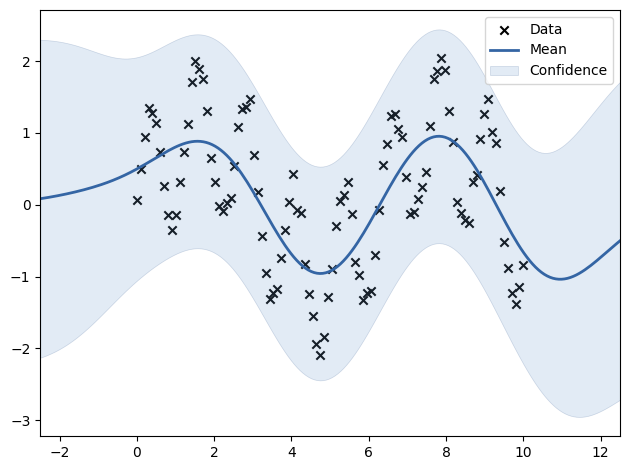

In [93]:
import numpy as np
import GPy

# Generate sample mixed-frequency data
X = np.linspace(0, 10, 100)[:, None]
Y_high_freq = np.sin(5 * X)  # High-frequency component
Y_low_freq = np.sin(X)       # Low-frequency component
Y = Y_high_freq + Y_low_freq + np.random.normal(0, 0.1, X.shape)

# Define a composite kernel: RBF for low-frequency, Periodic for high-frequency
kernel = GPy.kern.RBF(input_dim=1, variance=1.0, lengthscale=1.0) + \
         GPy.kern.PeriodicExponential(input_dim=1, variance=1.0, lengthscale=1.0, period=1.0)

# Fit the GPR model
model = GPy.models.GPRegression(X, Y, kernel)
model.optimize(messages=True)

# Predict and visualize
X_pred = np.linspace(0, 10, 200)[:, None]
Y_pred, Y_var = model.predict(X_pred)
model.plot()
Y
